# Simulation of the Fermi-Hubbard model on the square lattice 

### Hamiltonian evolution

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from src.resource_estimates.gate_costs.hamming_weight_phasing import HWPGate
from src.resource_estimates.gate_costs.free_fermionic import FreeFermionicC4Tile
from src.resource_estimates.gate_costs.interactions import ShiftedOccupationPair
from src.resource_estimates.gate_costs.hubbard_commutators import (
    SpinSymmetricMixedControlledKappa, 
    SpinSymmetricMixedControlledHappa,
    MixedControlledHappa
)
from src.resource_estimates.gate_costs.fermionic_swap import fswap_network_count, Fswap

from src.resource_estimates.hamiltonian_simulation import hamiltonian_simulation_cost
from src.resource_estimates.quantum_phase_estimation import adaptive_phase_estimation_resources

from src.hubbard_models.square_hubbard_model import (
    compute_number_of_trotter_steps,
    compute_evolution_time_and_number_of_simulation_circuits_for_qpe,
    plaquette_decomposition_permutations,
    augmented_permutations,
)

figsz = (7, 16)

In [2]:
tau = 1
U = 4
x = 0.01

def get_trotter_count_func(type: str, s: int):
    def f(t,e):
        return compute_number_of_trotter_steps(
            t,e,U,tau,s, type
        )
    return f

def gates_2nd_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 3,
        HWPGate({ShiftedOccupationPair():L**2}, m): 1,
        Fswap(): 4*fswap_network_count(plaquette_decomposition_permutations(L)),
    }, {HWPGate({ShiftedOccupationPair():L**2}, m): 1}

def gates_4th_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 15,
        HWPGate({ShiftedOccupationPair():L**2}, m): 5,
        Fswap(): 5*4*fswap_network_count(plaquette_decomposition_permutations(L)),
    }, {HWPGate({ShiftedOccupationPair():L**2}, m): 1}

def gates_augmented(L: int) -> tuple[dict, ...]:
    m = L**2//2
    aug_counts = {x: fswap_network_count(y) for x,y in augmented_permutations(L).items()}
    fswap_count = 2*(4*fswap_network_count(plaquette_decomposition_permutations(L))
                +2*aug_counts["red_to_augred"] + 2*aug_counts["augred_to_augblue"]
                +2*aug_counts["red_reflection"]
        )
    return {
       HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 6,
         HWPGate({ShiftedOccupationPair():L**2}, m): 2,
        HWPGate({SpinSymmetricMixedControlledHappa(): L**2 // 2}, m): 4,
        Fswap(): fswap_count
    }, {HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 5, HWPGate({SpinSymmetricMixedControlledKappa(): L**2//2}, m): 8}

def dict_to_t_count(dct: dict) -> int:
    tc = 0
    if "t" in dct.keys():
        tc += dct["t"] 
        
    if "tdg" in dct.keys():
        tc += dct["tdg"] 
        
    if "toffoli" in dct.keys():
        tc += 4*dct["toffoli"]
    return tc

def dict_to_t_depth(dct: dict) -> int:
    td = 0
    if "t_depth" in dct.keys():
        td += dct["t_depth"] 
        
    if "toffoli_depth" in dct.keys():
        td += 4*dct["toffoli_depth"]
    return td


def dict_to_cx_count(dct: dict) -> int:
    cxc = 0
    if "cx" in dct.keys():
        cxc += dct["cx"] 
        
    if "toffoli" in dct.keys():
        cxc += 4*dct["toffoli"]

    if "fswap" in dct.keys():
        cxc += 2*dct["fswap"]
    return cxc

/home/aftkvantify/lie-algebra-trotterization/src/resource_estimates/rotation_synthesis.py:43: UserWarning: When synthesizing rotation into clifford plus T, this function does not compute the single-qubit clifford count due to arbitrary rotations.
  warnings.warn(


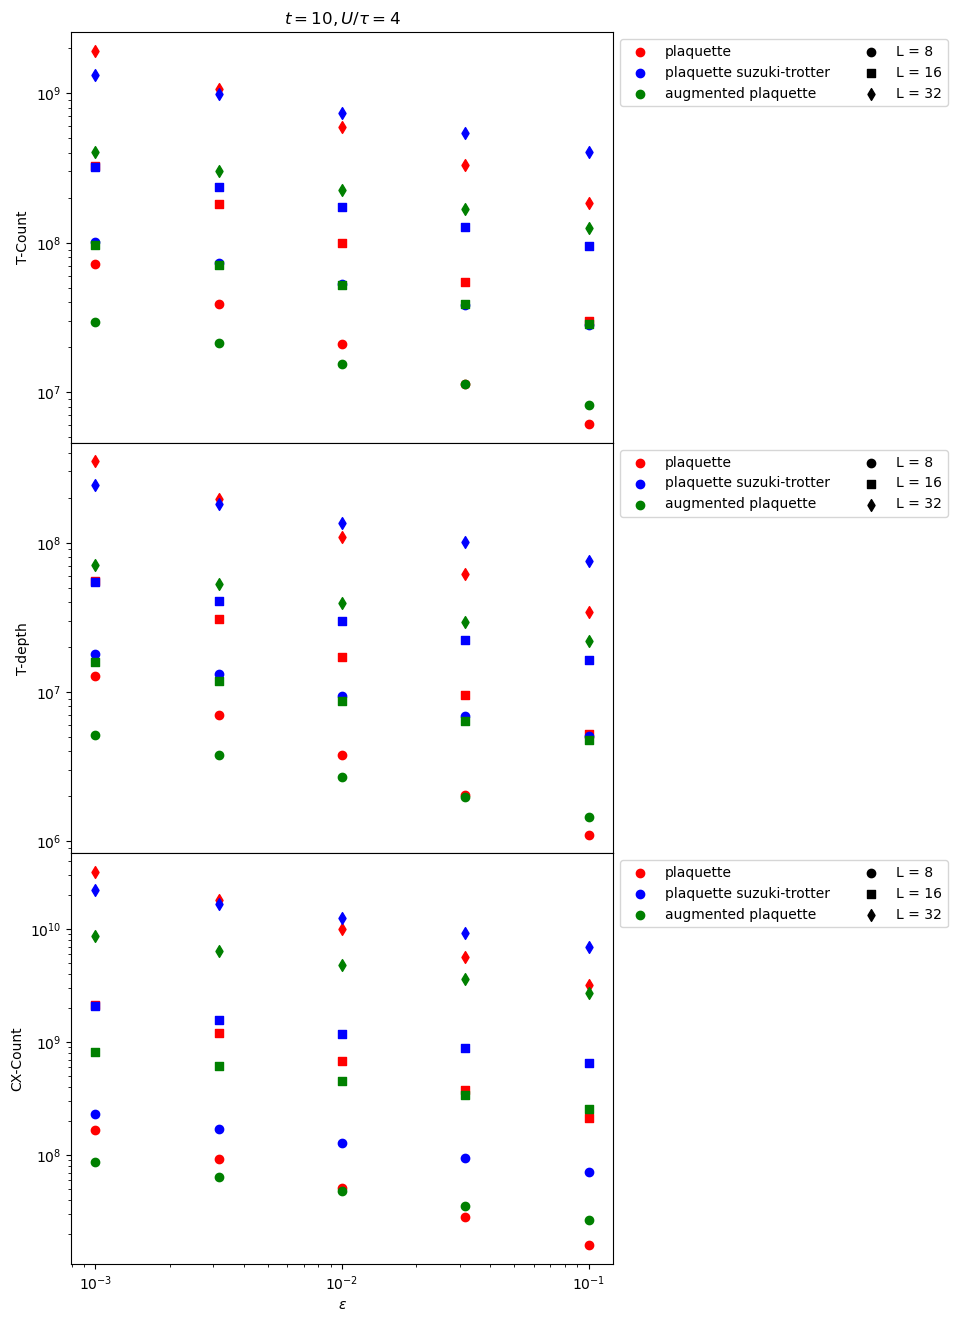

In [3]:
t = 10
logeps_list = np.linspace(-3, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [8, 16, 32]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette"]

fig, (ax_t, ax_td, ax_cx) = plt.subplots(3,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_t.set_title(rf"$t = {t}, U / \tau = {U}$")
ax_cx.set_xlabel(rf"$\varepsilon$")

for ax, g in zip([ax_t, ax_td, ax_cx], ["T-Count", "T-depth", "CX-Count"]):
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(f"{g}")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented], colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(L)
        dcts = [hamiltonian_simulation_cost(
            t, 
            e, 
            t_gates, 
            outer_gates=u_gates, 
            trotter_steps_from_time_and_error=get_trotter_count_func(comp_strat, L),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for e in eps_list
               ]
        ys_t = [dict_to_t_count(d) for d in dcts]
        ys_td = [dict_to_t_depth(d) for d in dcts]
        ys_cx = [dict_to_cx_count(d) for d in dcts]
        ax_t.scatter(eps_list, ys_t, marker = marker_style, c = color)
        ax_td.scatter(eps_list, ys_td, marker = marker_style, c = color)
        ax_cx.scatter(eps_list, ys_cx, marker = marker_style, c = color)

plaquette
t count: [615116, 1338664, 2969216, 6489324, 14172600, 30963972, 68549116, 149666952, 326723268, 722341868]
t depth: [110539, 240265, 531781, 1161039, 2533221, 5529315, 12218991, 26655321, 58139655, 128330983]
cx count: [1593936, 3438396, 7450536, 16145364, 34966848, 75767916, 164147928, 355623492, 770438064, 1669069692]
t count: [3008892, 6537388, 14185932, 31058476, 67436316, 146433436, 317949932, 695633164, 1510164108, 3278233932]
t depth: [523755, 1135189, 2457595, 5356639, 11605297, 25145991, 54483785, 118709997, 257186523, 557176425]
cx count: [21314796, 45941132, 99007916, 213573948, 460608172, 993505004, 2142913596, 4622029516, 9969368268, 21502984716]
t count: [18480696, 40069504, 86607492, 187181832, 404567388, 877355476, 1896370680, 4098914124, 8859499808, 19210824648]
t depth: [3430137, 7413693, 15999135, 34525353, 74508615, 161097719, 347689125, 750402807, 1619556145, 3501587485]
cx count: [320001876, 689394552, 1485481788, 3200589888, 6894911040, 14857615236, 32

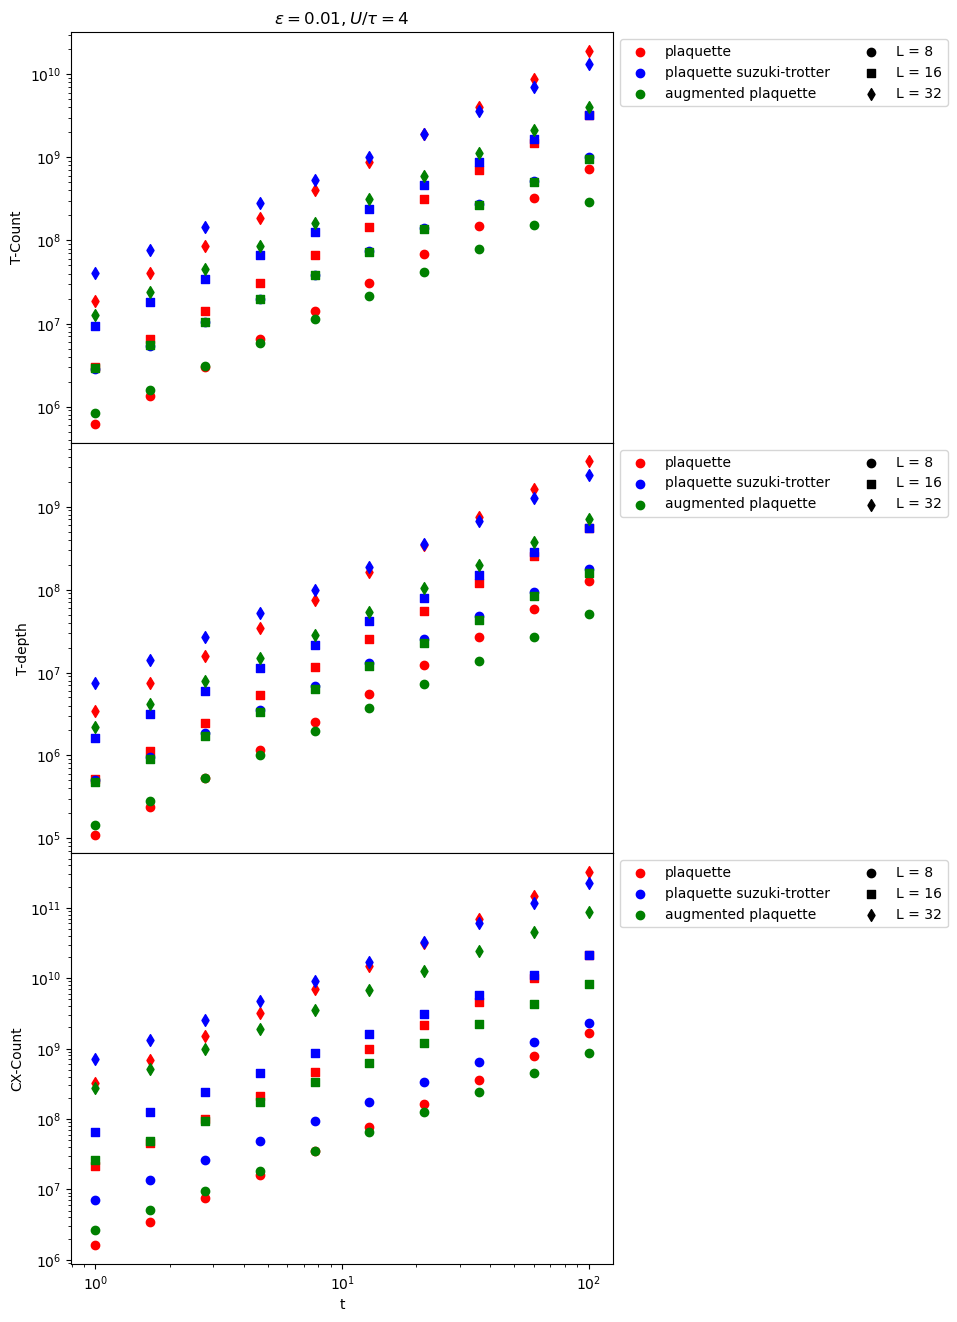

In [4]:
logts = np.linspace(0, 2, 10)
ts = np.pow(10, logts)
eps = 0.01
Ls = [8, 16, 32]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette"]

fig, (ax_t, ax_td, ax_cx) = plt.subplots(3,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_t.set_title(rf"$\varepsilon = {eps}, U / \tau = {U}$")
ax_cx.set_xlabel(rf"t")

for ax, g in zip([ax_t, ax_td, ax_cx], ["T-Count", "T-depth", "CX-Count"]):
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(f"{g}")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented], colors, comp_strats):
    print(comp_strat)
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(L)
        dcts = [hamiltonian_simulation_cost(
            t, 
            eps, 
            t_gates, 
            outer_gates=u_gates, 
            trotter_steps_from_time_and_error=get_trotter_count_func(comp_strat, L),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for t in ts
               ]
        ys_t = [dict_to_t_count(d) for d in dcts]
        ys_td = [dict_to_t_depth(d) for d in dcts]
        ys_cx = [dict_to_cx_count(d) for d in dcts]
        print("t count:", ys_t)
        print("t depth:", ys_td)
        print("cx count:", ys_cx)
        ax_t.scatter(ts, ys_t, marker = marker_style, c = color)
        ax_td.scatter(ts, ys_td, marker = marker_style, c = color)
        ax_cx.scatter(ts, ys_cx, marker = marker_style, c = color)

# Quantum Phase Estimation

In [5]:
tau = 1
U = 4
x = 0.01

import math

def qubitization_t_count(eps: float, N: int) -> int:
    return math.ceil((20*np.sqrt(2) * np.pi* tau + 5*np.sqrt(2) * np.pi*U) * (2*N)**2 / eps)

def qubitization_t_depth(eps: float, N: int) -> int:
    return math.ceil(qubitization_t_count(eps, N) / 4)  
    
def get_evolution_time_and_count_func(type: str, s: int):
    def f(e):
        return compute_evolution_time_and_number_of_simulation_circuits_for_qpe(
            e,U,tau,s, type, unitary_decomp=False
        )
    return f


def get_trotter_count_func(type: str, s: int):
    def f(t,e):
        return compute_number_of_trotter_steps(
            t,e,U,tau,s, type, 
        )
    return f

def gates_2nd_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 3,
        HWPGate({ShiftedOccupationPair():L**2}, 2*m): 1,
        Fswap(): 4*fswap_network_count(plaquette_decomposition_permutations(L)),
    }, {HWPGate({ShiftedOccupationPair():L**2}, 2*m): 1}

def gates_4th_order(L: int) -> tuple[dict, ...]:
    m = L**2//2
    return {
        HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 15,
        HWPGate({ShiftedOccupationPair():L**2}, 2*m): 5,
        Fswap(): 5*4*fswap_network_count(plaquette_decomposition_permutations(L)),
    }, {HWPGate({ShiftedOccupationPair():L**2}, 2*m): 1}

def gates_augmented(L: int) -> tuple[dict, ...]:
    m = L**2//2
    aug_counts = {x: fswap_network_count(y) for x,y in augmented_permutations(L).items()}
    fswap_count = 2*(4*fswap_network_count(plaquette_decomposition_permutations(L))
                +2*aug_counts["red_to_augred"] + 2*aug_counts["augred_to_augblue"]
                +2*aug_counts["red_reflection"]
        )
    return {
       HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 6,
         HWPGate({ShiftedOccupationPair():L**2}, 2*m): 2,
        HWPGate({SpinSymmetricMixedControlledHappa(): L**2 // 2}, m): 4,
        Fswap(): fswap_count
    }, {HWPGate({FreeFermionicC4Tile():L**2 // 2}, m): 6, HWPGate({SpinSymmetricMixedControlledKappa(): L**2//2}, m): 8}

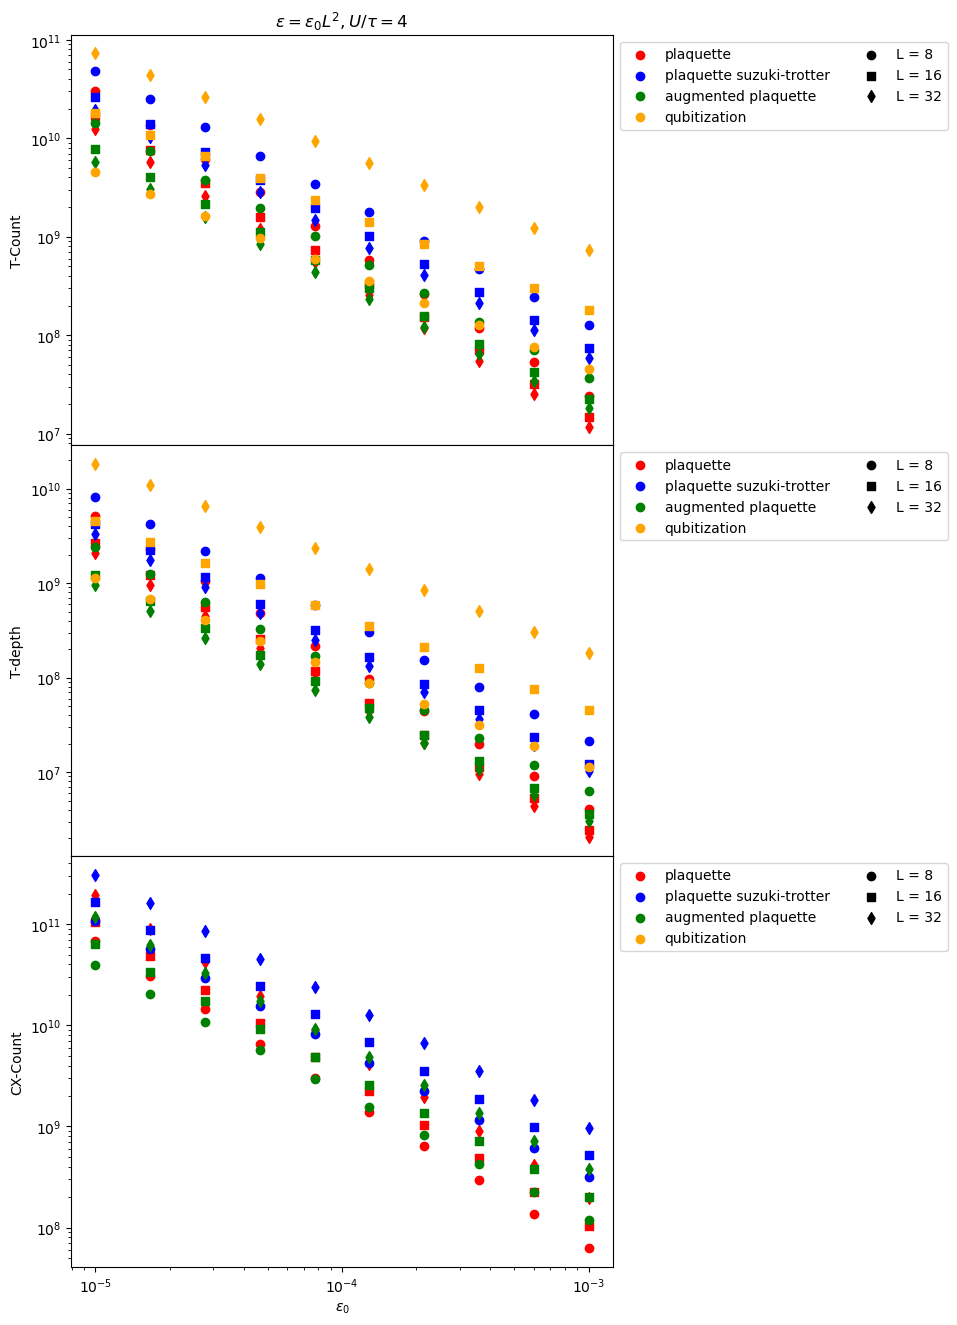

In [6]:
logeps_list = np.linspace(-5, -3, 10)
eps_list = np.pow(10, logeps_list)
Ls = [8, 16, 32]

colors = ['r', 'b', 'g', "orange"]
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette", "qubitization"]

fig, (ax_t, ax_td, ax_cx) = plt.subplots(3,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_t.set_title(rf"$\varepsilon = \varepsilon_0 L^2, U / \tau = {U}$")
ax_cx.set_xlabel(rf"$\varepsilon_0$")

for ax, g in zip([ax_t, ax_td, ax_cx], ["T-Count", "T-depth", "CX-Count"]):
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
    for L, marker in zip(Ls, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(f"{g}")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented, _], colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        if comp_strat == "qubitization":
            ys_t = [qubitization_t_count(e * L**2, L**2) for e in eps_list]
            ys_td = [qubitization_t_depth(e * L**2, L**2) for e in eps_list]
            ax_t.scatter(eps_list, ys_t, marker = marker_style, c = color)
            ax_td.scatter(eps_list, ys_td, marker = marker_style, c = color)
        else:
            t_gates, u_gates = gate_gen(L)
            dcts = [adaptive_phase_estimation_resources(
                e * L**2, 
                t_gates, 
                unitary_gates=u_gates, 
                simulation_steps_and_time_from_error=get_evolution_time_and_count_func(comp_strat, L),
                x=x,
                synthesize_rotation_with="RUS"
            )
                for e in eps_list
                   ]
            ys_t = [dict_to_t_count(d) for d in dcts]
            ys_td = [dict_to_t_depth(d) for d in dcts]
            ys_cx = [dict_to_cx_count(d) for d in dcts]
            ax_t.scatter(eps_list, ys_t, marker = marker_style, c = color)
            ax_td.scatter(eps_list, ys_td, marker = marker_style, c = color)
            ax_cx.scatter(eps_list, ys_cx, marker = marker_style, c = color)

plaquette
t count: [431540388, 1041572688, 2074361904, 3569517237, 5824932138, 8735137914, 12754372056]
t depth: [73428265, 169672677, 334848684, 595072767, 969857103, 1484096559, 2164462879]
cx count: [1047117716, 4555193388, 13554773508, 32020732139, 65200380750, 119200912110, 201626816828]
t count: [1249836826, 2997185248, 5984060361, 10193540109, 16672398480, 24936563100, 36366301998]
t depth: [212448639, 487068873, 961444486, 1695076942, 2764705686, 4222784340, 6150743113]
cx count: [2990944190, 12935160028, 38455516507, 90665658583, 184545647160, 337303928934, 570480825192]
t count: [15119194464, 35513488842, 69953945694, 117781971510, 191544583872, 284798559936, 413108109825]
t depth: [2561736848, 5726135715, 11123825694, 19419972051, 31472633754, 47868235646, 69410129822]
cx count: [34257974520, 146050724610, 432124073122, 1016397412930, 2066954551248, 3775454929696, 6383601778901]
plaquette suzuki-trotter
t count: [1397835616, 2705808642, 4681744602, 7141671114, 10626317920, 1

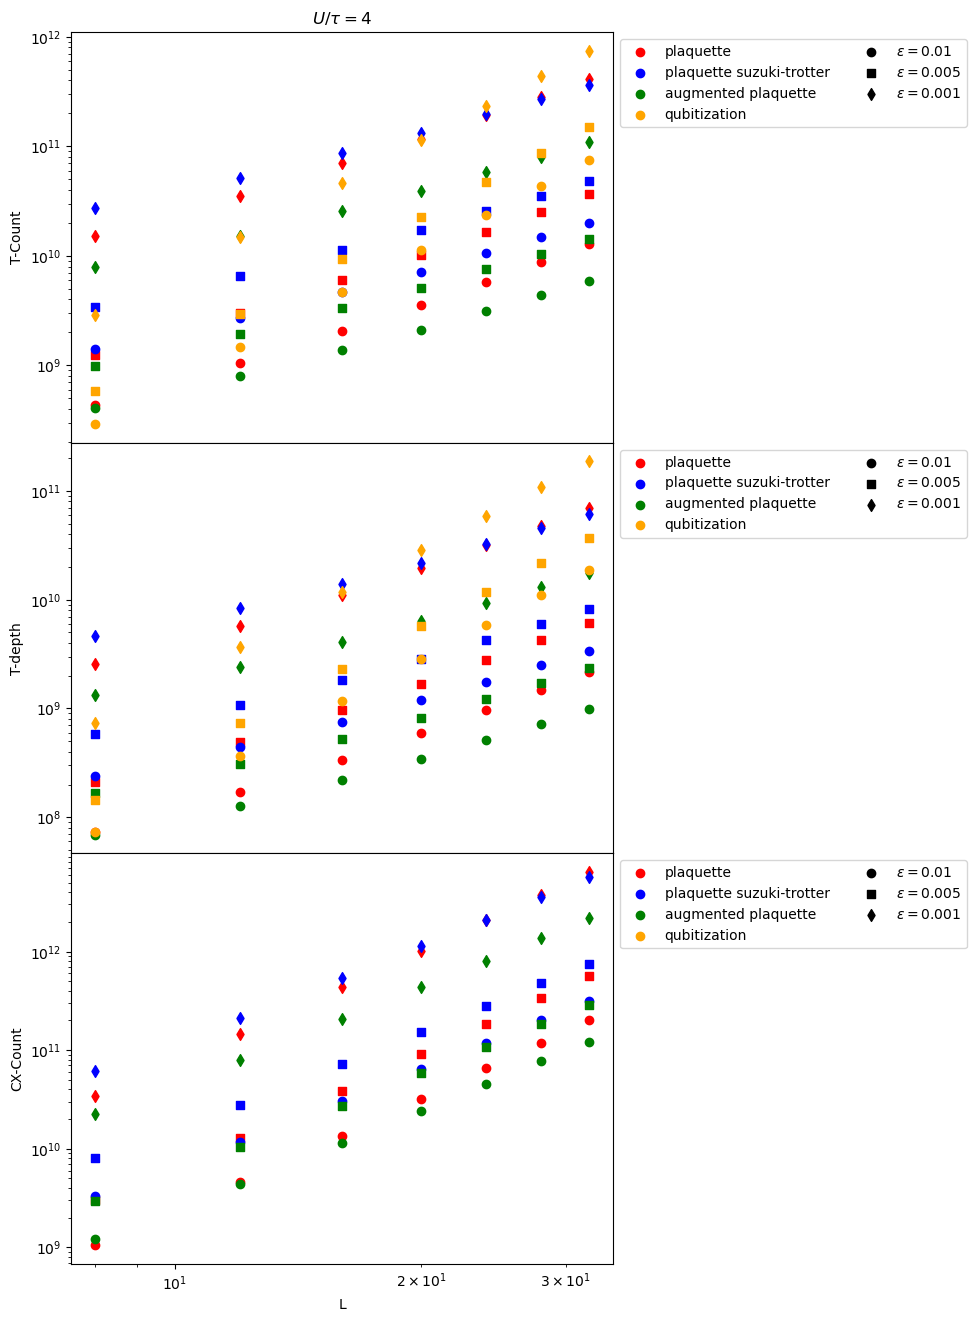

In [7]:
Ls = [8, 12, 16, 20, 24, 28, 32]
epss = [0.01, 0.005, 0.001]

colors = ['r', 'b', 'g', "orange"]
marker_styles = ['o', 's', 'd']
comp_strats = ["plaquette", "plaquette suzuki-trotter", "augmented plaquette", "qubitization"]

fig, (ax_t, ax_td, ax_cx) = plt.subplots(3,1, figsize = figsz, sharex = True)
fig.subplots_adjust(wspace=0, hspace=0)
ax_t.set_title(rf"$U / \tau = {U}$")
ax_cx.set_xlabel(rf"L")

for ax, g in zip([ax_t, ax_td, ax_cx], ["T-Count", "T-depth", "CX-Count"]):
    for strat, color in zip(comp_strats, colors):
        ax.scatter([],[], c = color, marker = "o", label = strat)
    for e, marker in zip(epss, marker_styles):
        ax.scatter([],[], c = "k", marker = marker, label = rf"$\varepsilon = {e}$")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(ncol = 2, loc = "upper left", bbox_to_anchor = (1.0,1.0))
    ax.set_ylabel(f"{g}")

for gate_gen, color, comp_strat in zip([gates_2nd_order, gates_4th_order, gates_augmented, "_"], colors, comp_strats):
    print(comp_strat)
    for e, marker_style in zip(epss, marker_styles):
        if comp_strat == "qubitization":
            ys_t = [qubitization_t_count(e , L**2) for L in Ls]
            ys_td = [qubitization_t_depth(e , L**2) for L in Ls]
            ax_t.scatter(Ls, ys_t, marker = marker_style, c = color)
            ax_td.scatter(Ls, ys_td, marker = marker_style, c = color)
        else:
            ys_t, ys_td, ys_cx = [], [], []
            for L in Ls:
                t_gates, u_gates = gate_gen(L)
                dct = adaptive_phase_estimation_resources(
                    e, 
                    t_gates, 
                    unitary_gates=u_gates, 
                    simulation_steps_and_time_from_error=get_evolution_time_and_count_func(comp_strat, L),
                    x=x,
                    synthesize_rotation_with="RUS"
                )
                ys_t.append(dict_to_t_count(dct))
                ys_td.append(dict_to_t_depth(dct))
                ys_cx.append(dict_to_cx_count(dct))
            ax_t.scatter(Ls, ys_t, marker = marker_style, c = color)
            ax_td.scatter(Ls, ys_td, marker = marker_style, c = color)
            ax_cx.scatter(Ls, ys_cx, marker = marker_style, c = color)
        print("t count:", ys_t)
        print("t depth:", ys_td)
        print("cx count:", ys_cx)
        